In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df= pd.read_csv("Bank_Customer_Churn_Prediction.csv")

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 12)

In [ ]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(['customer_id'], axis=1, inplace=True)

In [ ]:
df.shape

(10000, 11)

In [ ]:
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
df[num_cols].describe()

,credit_score,age,tenure,balance,products_number,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [ ]:
# num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary','active_member', 'credit_card' ]
# corr_cols = num_cols + ['churn']
# correlation_matrix = df[corr_cols].corr()
# correlation_matrix

In [ ]:
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

Text(0.5, 0, 'churn')

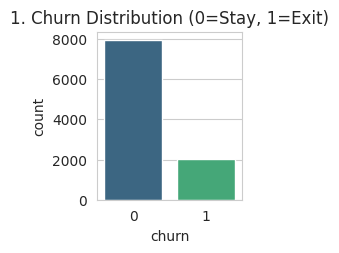

In [ ]:
plt.subplot(2, 3, 1)
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('1. Churn Distribution (0=Stay, 1=Exit)')
plt.xlabel('churn')

Text(0.5, 1.0, '2. Churn Rate by Gender')

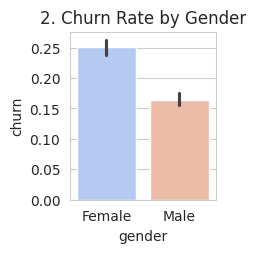

In [ ]:
plt.subplot(2, 3, 2)
sns.barplot(x='gender', y='churn', data=df, palette='coolwarm')
plt.title('2. Churn Rate by Gender')


Text(0.5, 1.0, '3. Churn Rate by Country')

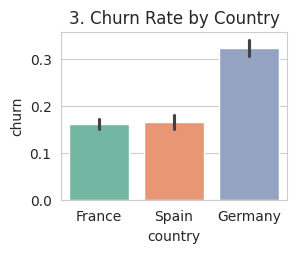

In [ ]:
plt.subplot(2, 2, 3)
sns.barplot(x='country', y='churn', data=df, palette='Set2')
plt.title('3. Churn Rate by Country')

Text(0.5, 1.0, '4. Age vs Balance by Churn')

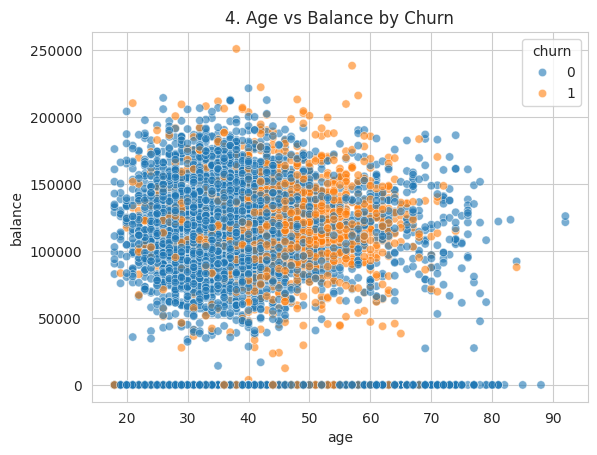

In [ ]:
# plt.subplot(2, 3, 4)
sns.scatterplot(x='age', y='balance', hue='churn', data=df, alpha=0.6)
plt.title('4. Age vs Balance by Churn')

Text(0.5, 1.0, '5. Correlation Heatmap')

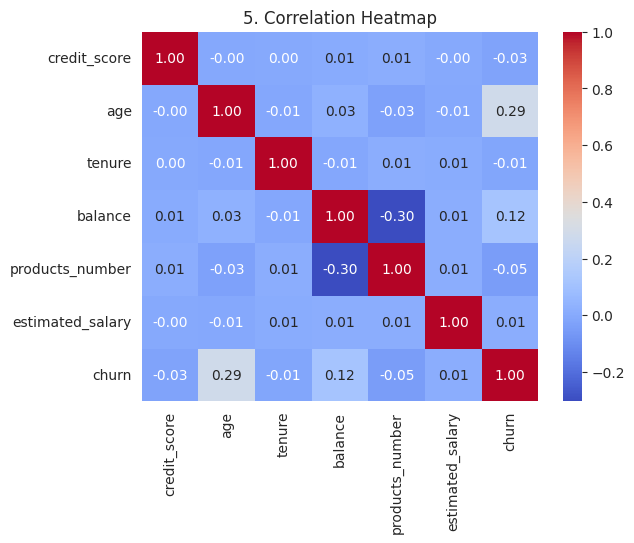

In [ ]:
# plt.subplot(2, 3, 5)
corr_data = df[num_cols + ['churn']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('5. Correlation Heatmap')

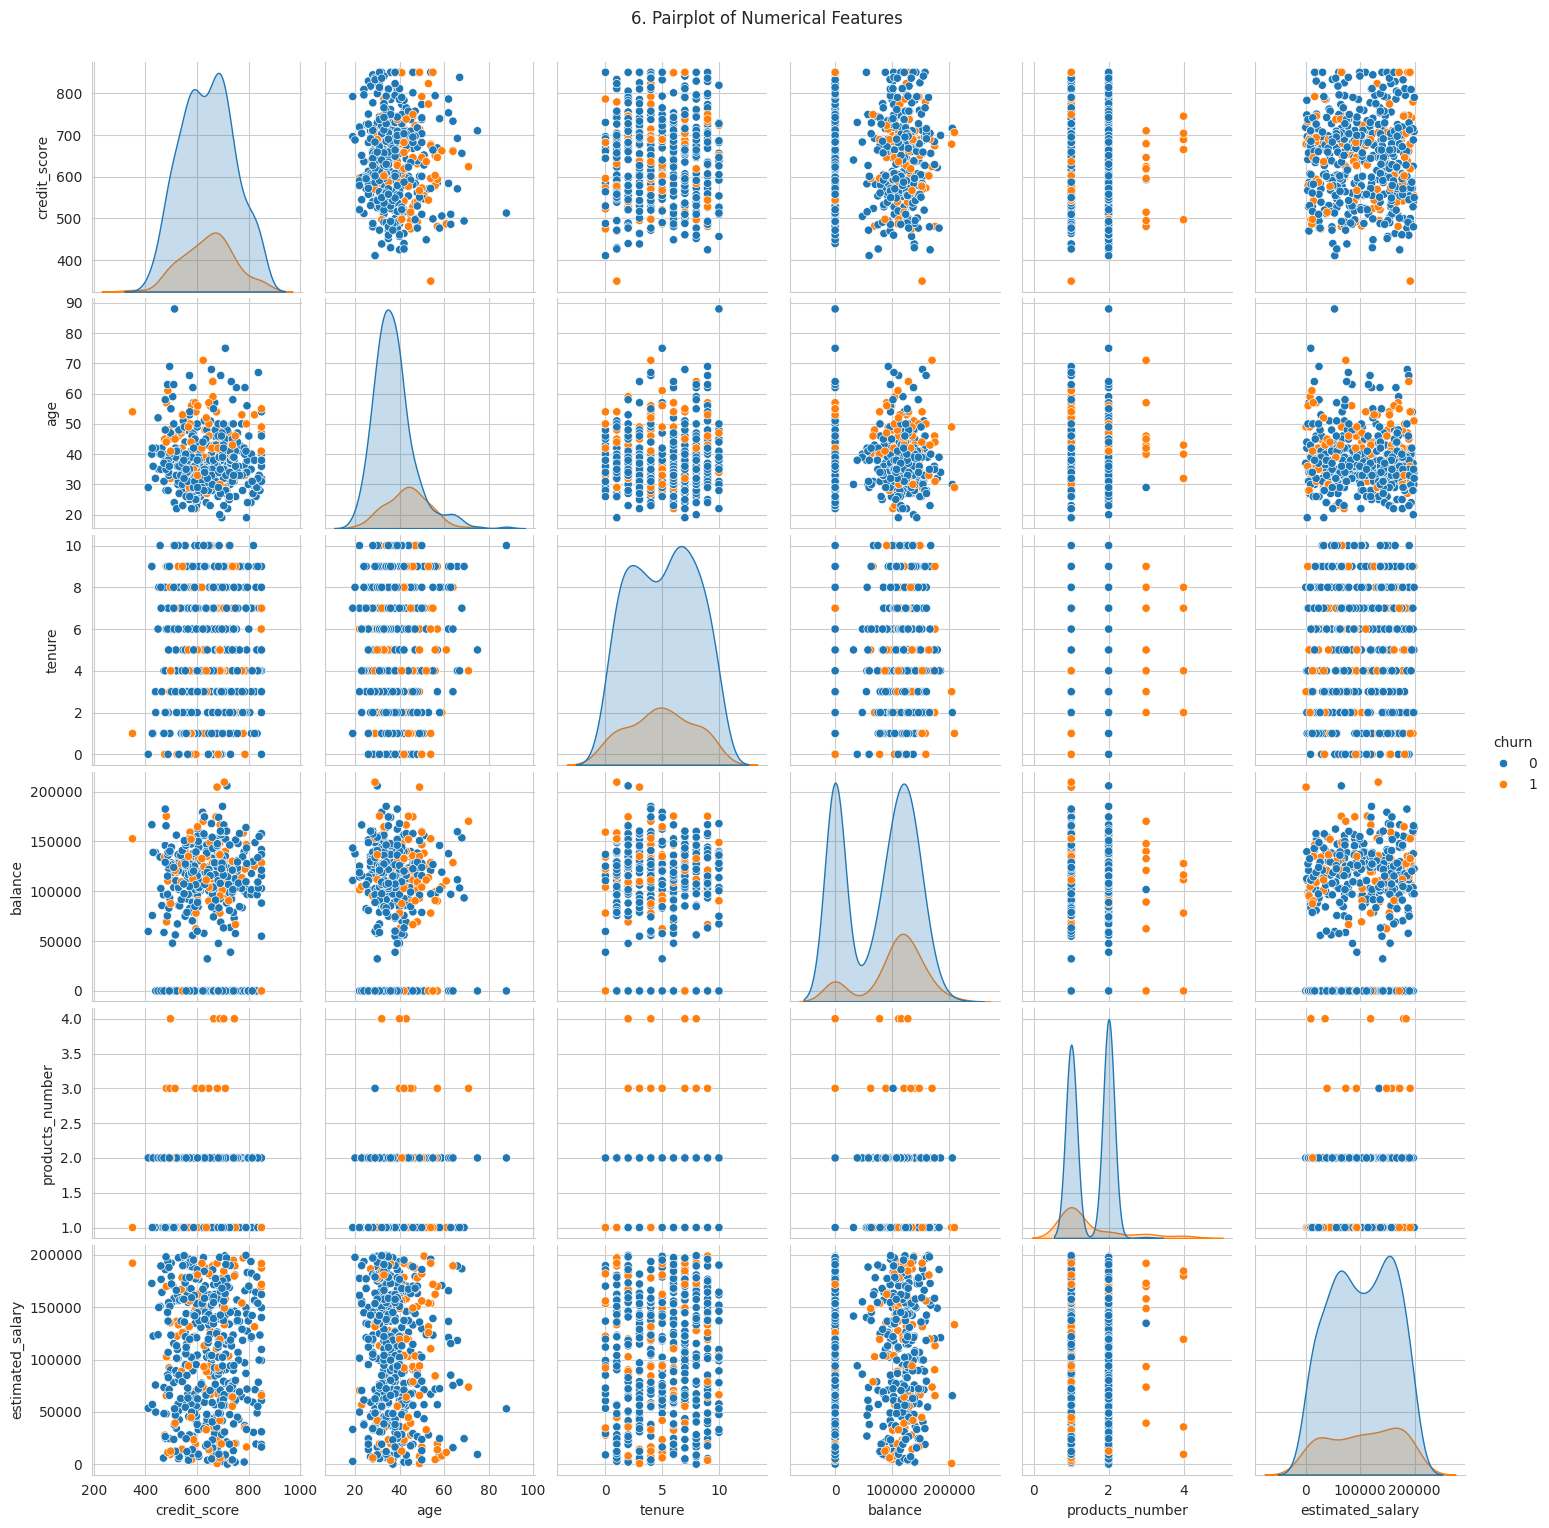

In [ ]:
sample_df = df[num_cols + ['churn']].sample(500, random_state=42)
pairplot_fig = sns.pairplot(sample_df, hue='churn', diag_kind='kde')
pairplot_fig.fig.suptitle('6. Pairplot of Numerical Features', y=1.02)
plt.show()

In [ ]:
X = df.drop('churn', axis=1)
y = df['churn']

In [ ]:
categorical_cols = ['country', 'gender']
numerical_cols = ['credit_score	', 'age', 'tenure', 'balance', 'products_number', 'estimatedsalary']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('female', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])


In [ ]:
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
categorical_cols = ['country', 'gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('female', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])



In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
X_train.shape[0]

8000

In [ ]:
X_test.shape[0]


2000

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

In [ ]:
results = {}

In [ ]:
predictions = {}


In [ ]:
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Predict on test set
    y_pred = model.predict(X_test)
    # Store predictions for later
    predictions[name] = y_pred
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} trained. Accuracy: {acc:.4f}")

Logistic Regression trained. Accuracy: 0.7945
Decision Tree trained. Accuracy: 0.8325
Random Forest trained. Accuracy: 0.8495



===== Logistic Regression =====
Accuracy: 0.7945
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1593
           1       0.48      0.13      0.20       407

    accuracy                           0.79      2000
   macro avg       0.65      0.55      0.54      2000
weighted avg       0.74      0.79      0.74      2000



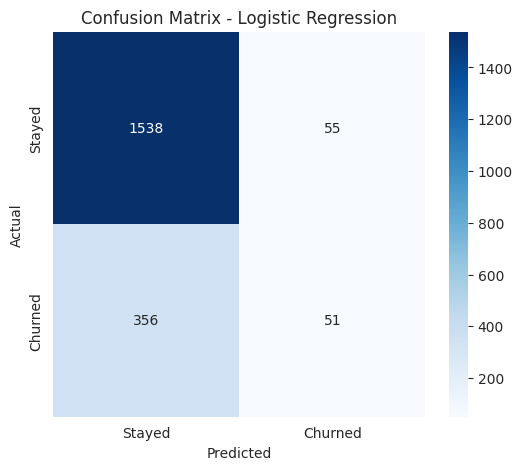


===== Decision Tree =====
Accuracy: 0.8325
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1593
           1       0.61      0.49      0.54       407

    accuracy                           0.83      2000
   macro avg       0.74      0.70      0.72      2000
weighted avg       0.82      0.83      0.83      2000



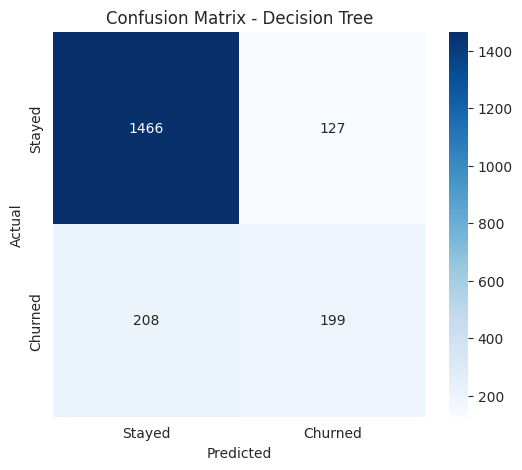


===== Random Forest =====
Accuracy: 0.8495
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1593
           1       0.71      0.45      0.55       407

    accuracy                           0.85      2000
   macro avg       0.79      0.70      0.73      2000
weighted avg       0.84      0.85      0.84      2000



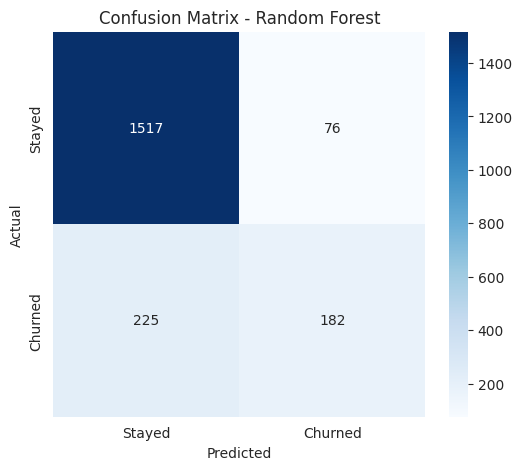

In [ ]:
for name, model in models.items():
    y_pred = predictions[name]

    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [ ]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
})
print(comparison_df.sort_values(by='Accuracy', ascending=False))


                 Model  Accuracy
2        Random Forest    0.8495
1        Decision Tree    0.8325
0  Logistic Regression    0.7945


In [ ]:
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name} with Accuracy: {results[best_model_name]:.4f}")


🏆 Best Model: Random Forest with Accuracy: 0.8495
